<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
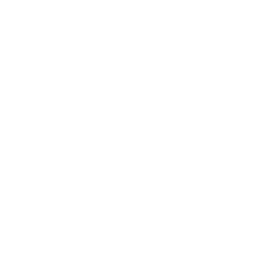
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Residential Energy Audit Consumption Estimates</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Building Performance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A residential energy-audit program samples households with unequal selection probabilities driven by their utility billing tier, deliberately oversampling high-consumption homes. This notebook uses **PROC SURVEYMEANS** to recover unbiased population estimates of mean annual electricity, natural-gas, and energy-cost consumption from that design. The audit data are stratified by building type and climate zone (20 strata) and weighted to represent the full residential population. Domain analysis then breaks the estimates down by building type and insulation grade, and the design-weighted means are fed into PROC SGPLOT to identify the high-consumption building segments that a utility demand-side management program should target — each with a properly calibrated 95% confidence interval.


## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.ENERGY_AUDIT | Residential audit results with design variables (stratum, weight) | 4,113 |
| WORK.BUILDING_CHARACTERISTICS | Structural and equipment detail | 5,000 |

The audit table is generated across 20 strata (4 building types x 5 climate zones) with a household-level audit weight that is smaller for oversampled high-consumption homes. The sum of weights represents roughly 632,000 households in the target population.


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic residential energy audit data
   Stratified by building type and climate zone
   Weighted for unequal selection probabilities
   -------------------------------------------------------- */
data work.energy_audit;
    call streaminit(42);
    array bldg_types[4] $20 _temporary_ (
        'SINGLE_FAMILY' 'TOWNHOUSE' 'LOW_RISE_APT' 'MOBILE_HOME');
    array climate_zones[5] $15 _temporary_ (
        'HOT_HUMID' 'HOT_DRY' 'MIXED_HUMID' 'COLD' 'VERY_COLD');
    array heat_fuels[3] $15 _temporary_ (
        'NATURAL_GAS' 'ELECTRIC' 'FUEL_OIL');
    obs_id = 0;
    do bldg_idx = 1 to 4;
        building_type = bldg_types[bldg_idx];
        do clim_idx = 1 to 5;
            climate_zone = climate_zones[clim_idx];
            stratum_id = (bldg_idx - 1) * 5 + clim_idx;
            n_hh = int(rand('uniform') * 150) + 150;
            do hh_seq = 1 to n_hh;
                obs_id + 1;
                household_id = obs_id;
                fuel_idx = int(rand('uniform') * 3) + 1;
                heating_fuel = heat_fuels[fuel_idx];
                year_built = int(rand('uniform') * 60) + 1965;
                sqft = int(rand('normal', 1800, 700));
                if sqft < 400 then sqft = 400;
                if sqft > 5000 then sqft = 5000;
                n_occupants = int(rand('exponential') * 2) + 1;
                if n_occupants > 7 then n_occupants = 7;
                /* Energy consumption varies by climate and building */
                base_kwh = 8000 + (clim_idx - 3) * 1500
                    + sqft * 2.5;
                if building_type = 'MOBILE_HOME' then base_kwh = base_kwh * 1.25;
                else if building_type = 'LOW_RISE_APT' then base_kwh = base_kwh * 0.7;
                annual_kwh = round(max(2000,
                    rand('normal', base_kwh, 3000)), 1);
                annual_therm = round(max(0,
                    rand('normal', 500 + (clim_idx - 2) * 150, 200)), 1);
                if heating_fuel ^= 'NATURAL_GAS' then annual_therm = 0;
                annual_cost = round(annual_kwh * 0.13
                    + annual_therm * 1.05, 0.01);
                /* Oversampling high-consumption households */
                if annual_kwh > 15000 then
                    audit_weight = round(rand('uniform') * 50 + 30, 0.01);
                else
                    audit_weight = round(rand('uniform') * 200 + 100, 0.01);
                has_solar = ifc(rand('uniform') > 0.88, 'Y', 'N');
                insulation_grade = ifc(rand('uniform') > 0.6, 'ADEQUATE',
                    ifc(rand('uniform') > 0.4, 'MARGINAL', 'POOR'));
                output;
            end;
        end;
    end;
    drop bldg_idx clim_idx fuel_idx n_hh hh_seq base_kwh;
run;

NOTE: DATA work.energy_audit


NOTE: Wrote work.energy_audit (4113 rows, 15 columns).
NOTE: DATA elapsed:
  wall  1.69 seconds
  cpu   1.69 seconds


In [2]:
/* --------------------------------------------------------
   Generate building characteristics detail
   -------------------------------------------------------- */
data work.building_characteristics;
    call streaminit(44);
    array hvac_types[4] $20 _temporary_ (
        'CENTRAL_AC' 'HEAT_PUMP' 'WINDOW_UNIT' 'NONE');
    array roof_types[3] $15 _temporary_ (
        'ASPHALT_SHINGLE' 'METAL' 'TILE');
    do household_id = 1 to 5000;
        hvac_idx = int(rand('uniform') * 4) + 1;
        hvac_system = hvac_types[hvac_idx];
        hvac_age_years = int(rand('exponential') * 6) + 1;
        if hvac_age_years > 30 then hvac_age_years = 30;
        roof_idx = int(rand('uniform') * 3) + 1;
        roof_type = roof_types[roof_idx];
        n_windows = int(rand('uniform') * 15) + 4;
        pct_double_pane = round(rand('uniform') * 100, 1);
        duct_leakage_cfm = round(max(0, rand('normal', 120, 60)), 1);
        blower_door_cfm50 = round(max(500, rand('normal', 2800, 900)), 1);
        output;
    end;
    drop hvac_idx roof_idx;
run;

NOTE: DATA work.building_characteristics


NOTE: Wrote work.building_characteristics (5000 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.81 seconds
  cpu   0.81 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline energy consumption by building type
   -------------------------------------------------------- */
proc means data=work.energy_audit n mean std ;
    class building_type;
    var annual_kwh annual_therm annual_cost;
    title 'Unweighted Energy Consumption by Building Type';
run;

                                     Unweighted Energy Consumption by Building Type                                     

                                                  The MEANS Procedure

                                             Analysis Variable : ANNUAL_KWH

        BUILDING_TYPE          N Obs           Mean        Std Dev
        ----------------------------------------------------------
        LOW_RISE_APT             921   9216.9359392   3555.0560476
        MOBILE_HOME             1041  15688.5513929   4670.5161930
        SINGLE_FAMILY           1125  12783.9546667   4158.1279641
        TOWNHOUSE               1026  12772.0224172   3997.3478957
        ----------------------------------------------------------

                                            Analysis Variable : ANNUAL_THERM

        BUILDING_TYPE          N Obs           Mean        Std Dev
        ----------------------------------------------------------
        LOW_RISE_APT             921    213.5027

---

                                     Unweighted Energy Consumption by Building Type                                     

NOTE: PROC SGPLOT data=work.energy_audit

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


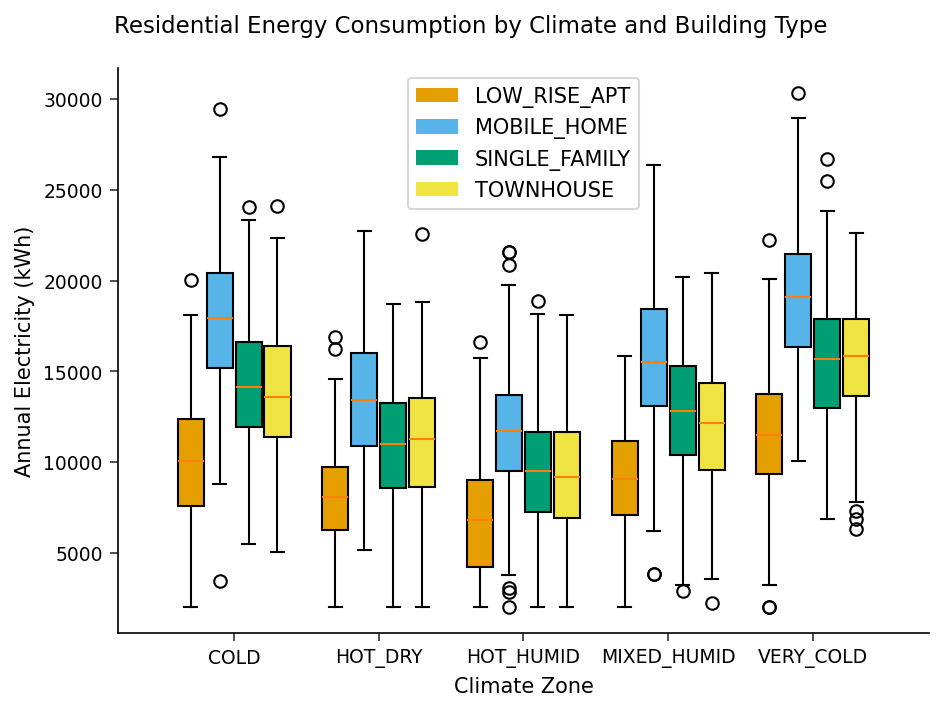

In [4]:
/* --------------------------------------------------------
   kWh distribution by climate zone and building type
   -------------------------------------------------------- */
proc sgplot data=work.energy_audit;
    vbox annual_kwh / category=climate_zone group=building_type;
    xaxis label='Climate Zone';
    yaxis label='Annual Electricity (kWh)';
    title 'Residential Energy Consumption by Climate and Building Type';
run;

---

In [5]:
/* Suppress the default SURVEYMEANS confidence-interval plot;
   the authored SGPLOT charts below tell the visual story. */
ods graphics off;

/* --------------------------------------------------------
   Estimate mean energy consumption using stratified
   design with unequal probability weights
   -------------------------------------------------------- */
ods output Statistics=work.energy_national_est;
proc surveymeans data=work.energy_audit
        mean stderr clm sum;
    strata stratum_id;
    weight audit_weight;
    var annual_kwh annual_therm annual_cost;
    title 'Population-Level Residential Energy Estimates';
run;


                                     Unweighted Energy Consumption by Building Type                                     


                        The SURVEYMEANS Procedure

     Number of Observations Read         4113
     Number of Observations Used         4113
     Sum of Weights                      631967.13
     Stratum Variable: stratum_id                20 Strata

Variable                N            Mean             Sum       Std Error        Lower CL        Upper CL
---------------------------------------------------------------------------------------------------------
annual_kwh           4113      11139.3970  7039732773.7100         49.9057      11041.5548      11237.2393
annual_therm         4113        206.2665  130353632.8300          5.8361        194.8246        217.7083
annual_cost          4113       1664.7014  1052036575.0538          8.9632       1647.1288       1682.2741
-------------------------------------------------------------------------------------------

In [6]:
/* --------------------------------------------------------
   Domain estimates by building type for targeted
   demand-side management program design
   -------------------------------------------------------- */
ods output Domain=work.energy_by_bldg;
proc surveymeans data=work.energy_audit
        mean stderr clm;
    strata stratum_id;
    weight audit_weight;
    var annual_kwh annual_cost;
    domain building_type;
    title 'Energy Estimates by Building Type';
run;


                                     Unweighted Energy Consumption by Building Type                                     


                        The SURVEYMEANS Procedure

     Number of Observations Read         4113
     Number of Observations Used         4113
     Sum of Weights                      631967.13
     Stratum Variable: stratum_id                20 Strata

building_type  Variable                N            Mean       Std Error        Lower CL        Upper CL
--------------------------------------------------------------------------------------------------------
              annual_kwh           4113      11139.3970         49.9057      11041.5548      11237.2393
              annual_cost          4113       1664.7014          8.9632       1647.1288       1682.2741
LOW_RISE_APT  annual_kwh            921       8974.0112        103.3731       8771.1356       9176.8868
LOW_RISE_APT  annual_cost           921       1384.6306         18.5263       1348.2716       1420.98

In [7]:
/* --------------------------------------------------------
   Domain estimates by insulation grade to quantify
   weatherization program savings potential
   -------------------------------------------------------- */
ods output Domain=work.energy_by_insulation;
proc surveymeans data=work.energy_audit
        mean stderr clm;
    strata stratum_id;
    weight audit_weight;
    var annual_kwh annual_cost;
    domain insulation_grade;
    title 'Energy Estimates by Insulation Grade';
run;

/* Re-enable ODS Graphics for the authored SGPLOT chart. */
ods graphics on;


                                     Unweighted Energy Consumption by Building Type                                     


                        The SURVEYMEANS Procedure

     Number of Observations Read         4113
     Number of Observations Used         4113
     Sum of Weights                      631967.13
     Stratum Variable: stratum_id                20 Strata

insulation_grade  Variable                N            Mean       Std Error        Lower CL        Upper CL
-----------------------------------------------------------------------------------------------------------
              annual_kwh           4113      11139.3970         49.9057      11041.5548      11237.2393
              annual_cost          4113       1664.7014          8.9632       1647.1288       1682.2741
    ADEQUATE  annual_kwh           1670      11199.2828         80.1740      11042.0293      11356.5363
    ADEQUATE  annual_cost          1670       1672.6259         14.2396       1644.6962       1

                                     Unweighted Energy Consumption by Building Type                                     

NOTE: DATA work.bldg_kwh


NOTE: Read 10 rows from work.energy_by_bldg.
NOTE: Wrote work.bldg_kwh (4 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.bldg_kwh

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


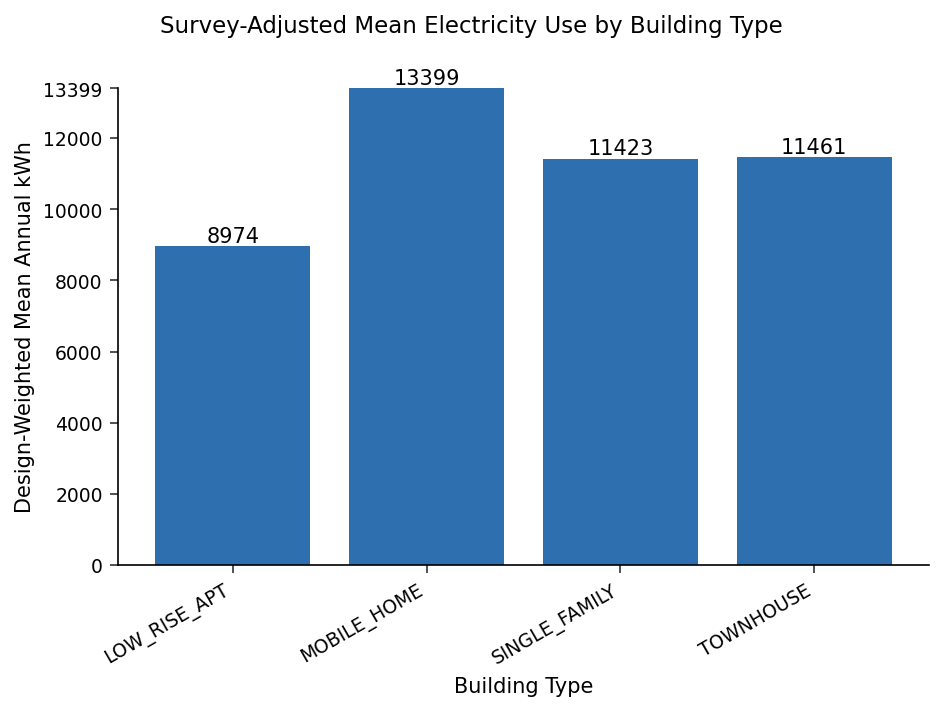

In [8]:
/* --------------------------------------------------------
   Feed the survey estimates into PROC SGPLOT.
   Keep the four building-type domains for the electricity
   variable (drop the overall blank-domain row) and chart the
   design-weighted mean of each segment. The exact 95%
   confidence limits for every bar are listed in the
   SURVEYMEANS domain table above; here we rank the segments
   so the demand-side management target stands out.
   -------------------------------------------------------- */
data work.bldg_kwh;
    set work.energy_by_bldg;
    where VarName = 'annual_kwh' and building_type ne ' ';
run;

proc sgplot data=work.bldg_kwh;
    vbar building_type / response=Mean
        fillattrs=(color=cx2E6FB0) datalabel
        baselineattrs=(thickness=0);
    xaxis label='Building Type';
    yaxis label='Design-Weighted Mean Annual kWh';
    title 'Survey-Adjusted Mean Electricity Use by Building Type';
run;


---

### Interpretation

Applying the stratified design weights, the population estimate for mean residential electricity consumption is **11,139 kWh per year** (standard error 49.9 kWh; 95% confidence limits 11,042 to 11,237 kWh), which scales to an estimated **7.04 billion kWh** total across the weighted population of about 632,000 households. The companion estimates are **206 therms** of natural gas (SE 5.8) and an **annual energy cost of \$1,665** per household (SE \$9.0). Because the audit oversampled high-consumption households at deliberately smaller weights, the design-weighted electricity mean (11,139 kWh) sits well below the unweighted sample average — confirming that ignoring the unequal selection probabilities would have overstated typical consumption.

The building-type domain estimates reveal the segments a demand-side management program should target. **Mobile homes are the most electricity-intensive segment at a weighted mean of 13,399 kWh** (95% CL 13,170 to 13,628), roughly 49% above **low-rise apartments at 8,974 kWh** (95% CL 8,771 to 9,177). Single-family homes (11,423 kWh) and townhouses (11,461 kWh) fall in between and are statistically indistinguishable from each other. The narrow, non-overlapping confidence limits for mobile homes versus apartments give the utility a statistically defensible basis for prioritizing the mobile-home segment for weatherization incentives.

By contrast, the insulation-grade domains show **no material difference in electricity use** — ADEQUATE (11,199 kWh), MARGINAL (11,050 kWh), and POOR (11,179 kWh) all overlap within their confidence limits. On this audit sample, self-reported insulation grade is not a useful screen for electricity-savings potential; building type is the far stronger discriminator. The survey-adjusted confidence intervals let the utility set savings targets and segment priorities that will withstand review by the public utilities commission.


---

In [9]:
/* --------------------------------------------------------
   Export energy estimates for program planning
   -------------------------------------------------------- */
proc export data=work.energy_national_est
    outfile='residential_energy_estimates.csv'
    dbms=csv replace;
run;

proc export data=work.energy_by_bldg
    outfile='energy_by_building_type.csv'
    dbms=csv replace;
run;

proc export data=work.energy_by_insulation
    outfile='energy_by_insulation_grade.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.energy_national_est outfile=residential_energy_estimates.csv

NOTE: Exported 8 rows to residential_energy_estimates.csv.
NOTE: PROC EXPORT data=work.energy_by_bldg outfile=energy_by_building_type.csv

NOTE: Exported 10 rows to energy_by_building_type.csv.
NOTE: PROC EXPORT data=work.energy_by_insulation outfile=energy_by_insulation_grade.csv

NOTE: Exported 8 rows to energy_by_insulation_grade.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>